In [25]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import h5py 
import sys 
import os 

plt.style.use('../../utils/dune.mplstyle')

In [26]:
#input_dir = Path('/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/single_photon')
#input_dir = Path('/pscratch/sd/l/lmlepin/grid_output/single_photons_test_v3/EDEPSIM')
#input_dir = Path('/pscratch/sd/l/lmlepin/grid_output/single_photons_test_box_volume/EDEPSIM')
input_dir = Path('/pscratch/sd/l/lmlepin/grid_output/gammas_4.4_MeV_setB/EDEPSIM')
#input_dir = Path('/pscratch/sd/l/lmlepin/grid_output/electrons_3.0_MeV_05-04-2026/EDEPSIM')
file_pattern = '*.EDEPSIM.hdf5'
max_files = None  # Set to an integer for a quick test run.

files = sorted(input_dir.glob(file_pattern))
if max_files is not None:
    files = files[:max_files]

assert files, f'No files matched {file_pattern} in {input_dir}'

print(f'Searching in: {input_dir}')
print(f'Pattern: {file_pattern}')
print(f'Found {len(files)} file(s)')
for file_path in files[:5]:
    print(f'  - {file_path.name}')
if len(files) > 5:
    print('  - ...')

Searching in: /pscratch/sd/l/lmlepin/grid_output/gammas_4.4_MeV_setB/EDEPSIM
Pattern: *.EDEPSIM.hdf5
Found 5 file(s)
  - 2x2_QGSP_BERT_HP_Gun_1778000338_0.EDEPSIM.hdf5
  - 2x2_QGSP_BERT_HP_Gun_1778000338_1.EDEPSIM.hdf5
  - 2x2_QGSP_BERT_HP_Gun_1778000401_2.EDEPSIM.hdf5
  - 2x2_QGSP_BERT_HP_Gun_1778000401_3.EDEPSIM.hdf5
  - 2x2_QGSP_BERT_HP_Gun_1778000457_4.EDEPSIM.hdf5


In [27]:
def _concat_or_empty(chunks, shape_tail=(), dtype=float):
    if not chunks:
        return np.empty((0,) + tuple(shape_tail), dtype=dtype)
    return np.concatenate(chunks, axis=0)


electron_energy_chunks = []
primary_xyz_chunks = []
total_events = 0
trajectory_keys = None
segment_keys = None
example_file = files[0]

for file_path in files:
    with h5py.File(file_path, 'r') as h5_file:
        trajectories = h5_file['trajectories']
        segments = h5_file['segments']

        if trajectory_keys is None:
            trajectory_keys = trajectories.dtype.names
            segment_keys = segments.dtype.names

        traj_arr = trajectories[:]
        total_events += len(np.unique(traj_arr['event_id']))

        electron_energy_chunks.append(
            traj_arr[np.abs(traj_arr['pdg_id']) == 11]['E_start'] - 0.511
        )

        primary_trajs = traj_arr[traj_arr['primary']]
        if len(primary_trajs) > 0:
            primary_xyz_chunks.append(np.asarray(primary_trajs['xyz_start']))

E_electrons = _concat_or_empty(electron_energy_chunks, dtype=np.float64)
primary_start_xyz = _concat_or_empty(primary_xyz_chunks, shape_tail=(3,), dtype=np.float64)

print(f'Example file: {example_file.name}')
print(f'Trajectories keys: {trajectory_keys}')
print(f'Segments keys: {segment_keys}')

Example file: 2x2_QGSP_BERT_HP_Gun_1778000338_0.EDEPSIM.hdf5
Trajectories keys: ('event_id', 'vertex_id', 'traj_id', 'file_traj_id', 'parent_id', 'primary', 'E_start', 'pxyz_start', 'xyz_start', 't_start', 'E_end', 'pxyz_end', 'xyz_end', 't_end', 'pdg_id', 'start_process', 'start_subprocess', 'end_process', 'end_subprocess', 'dist_travel')
Segments keys: ('event_id', 'vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE', 't', 'y', 'x', 'z', 'n_photons')


In [28]:
print(f'Number of events across all files: {total_events}')

Number of events across all files: 6296


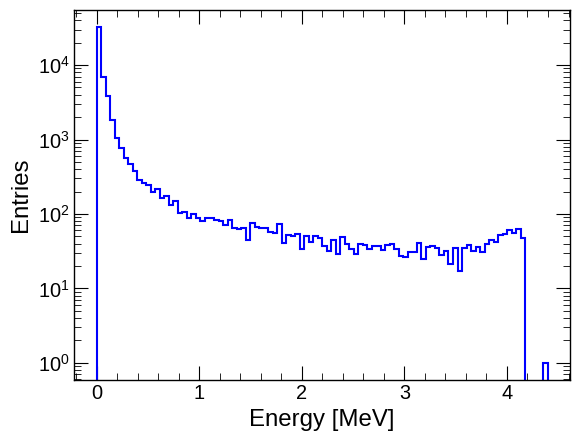

In [29]:
plt.hist(E_electrons, bins=100,histtype='step',color='blue')
plt.yscale('log')
plt.xlabel('Energy [MeV]')
plt.ylabel('Entries')
plt.show()

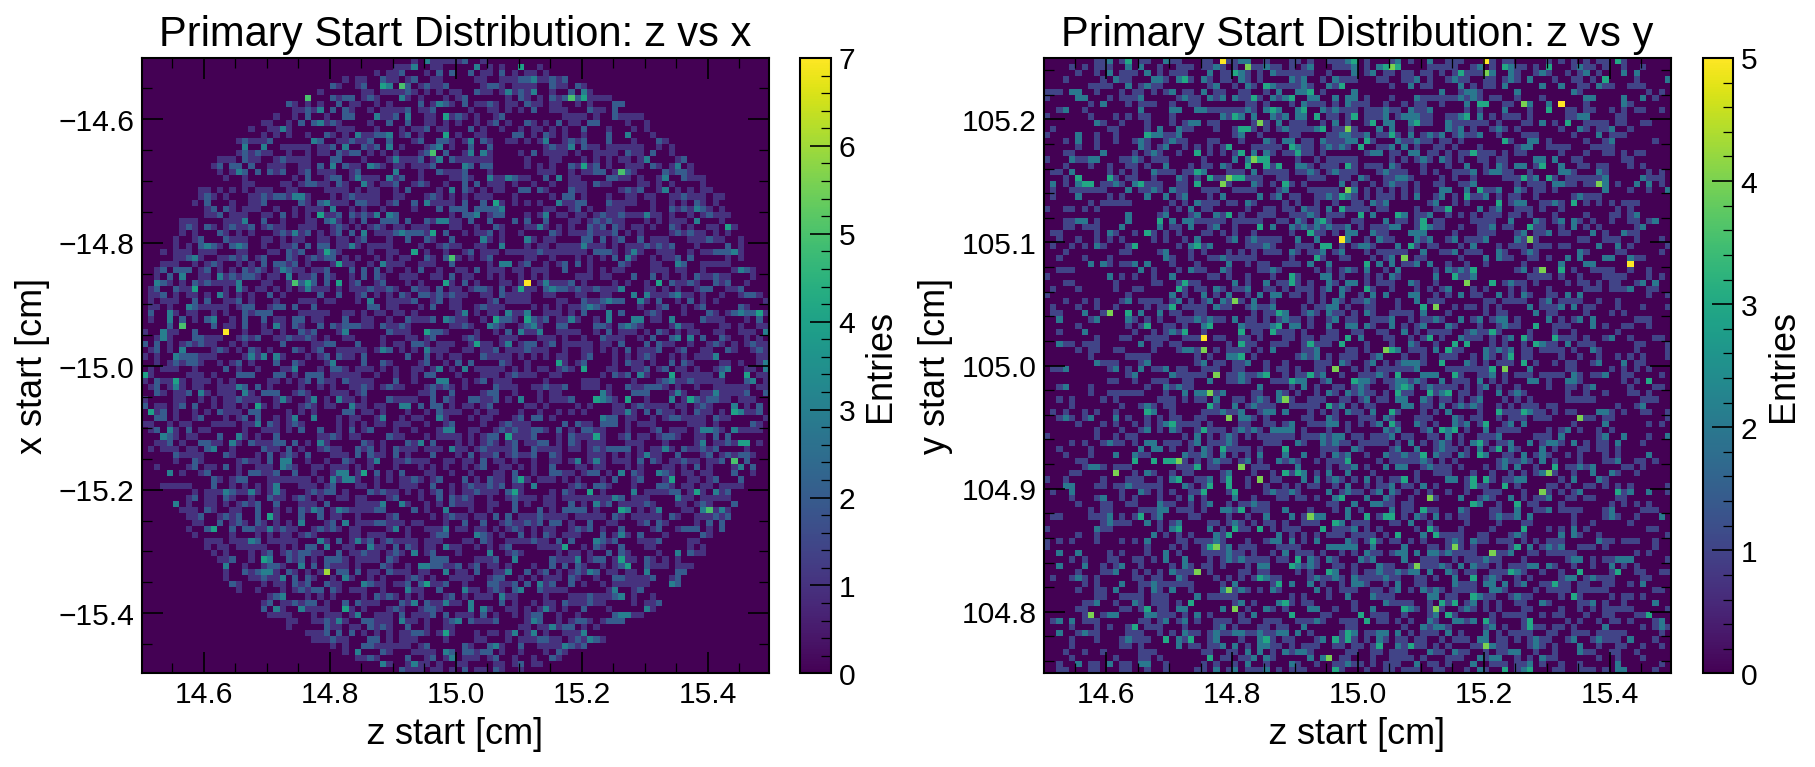

In [30]:
x_start = primary_start_xyz[:, 0]
y_start = primary_start_xyz[:, 1]
z_start = primary_start_xyz[:, 2]


fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150, constrained_layout=True)

hist_zx = axes[0].hist2d(z_start, x_start, bins=100, cmap='viridis')
axes[0].set_xlabel('z start [cm]')
axes[0].set_ylabel('x start [cm]')
axes[0].set_title('Primary Start Distribution: z vs x')
fig.colorbar(hist_zx[3], ax=axes[0], label='Entries')

hist_zy = axes[1].hist2d(z_start, y_start, bins=100, cmap='viridis')
axes[1].set_xlabel('z start [cm]')
axes[1].set_ylabel('y start [cm]')   
axes[1].set_title('Primary Start Distribution: z vs y')
fig.colorbar(hist_zy[3], ax=axes[1], label='Entries')

plt.show()


In [ ]:
import math

def larndsim_num_electrons(dE, dEdx, pdg_id=None, mode="birks"):
    """
    Match larnd-sim quenching.py.

    Parameters
    ----------
    dE : float
        Segment deposited energy in MeV.
    dEdx : float
        Segment energy loss in MeV/cm.
    pdg_id : int | None
        If 22 (gamma) or 2112 (neutron), larnd-sim returns 0 electrons.
    mode : str
        "birks" or "box". larnd-sim's CLI uses Birks.

    Returns
    -------
    float
        Number of ionization electrons after recombination.
    """
    # larnd-sim constants
    BOX_ALPHA = 0.93
    BOX_BETA = 0.207      # (kV/cm)(g/cm^2)/MeV
    BIRKS_Ab = 0.800
    BIRKS_kb = 0.0486     # (kV/cm)(g/cm^2)/MeV
    W_ION = 23.6e-6       # MeV
    E_FIELD = 0.50        # kV/cm
    LAR_DENSITY = 1.38    # g/cm^3

    if dEdx <= 0:
        return 0.0
    if pdg_id in (22, 2112):
        return 0.0

    mode = mode.lower()
    if mode == "box":
        csi = BOX_BETA * dEdx / (E_FIELD * LAR_DENSITY)
        recomb = max(0.0, math.log(BOX_ALPHA + csi) / csi)
    elif mode == "birks":
        recomb = BIRKS_Ab / (1.0 + BIRKS_kb * dEdx / (E_FIELD * LAR_DENSITY))
    else:
        raise ValueError("mode must be 'birks' or 'box'")

    if math.isnan(recomb):
        raise RuntimeError("Invalid recombination value")

    return recomb * dE / W_ION
